**Environment Setup**

01- Import thr libraries

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

02-Define path to the image

In [13]:
image_path = 'lab2.jpg'

Load the image (OpenCV loads as BGR)

In [14]:
img_bgr = cv2.imread(image_path)

In [15]:
if img_bgr is None:
    print(" Image not found. Please upload 'lab2.jpg' to the Colab folder.")
else:
    # Convert BGR to RGB for correct display colors
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

03-Display the image

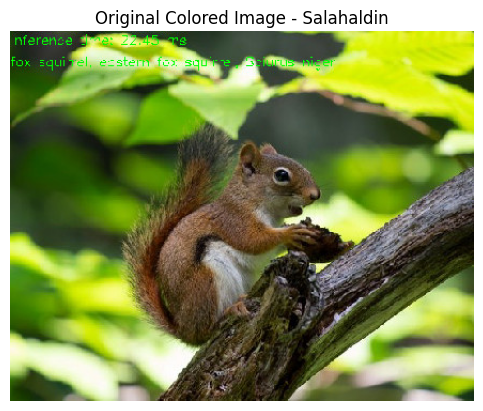

In [17]:
plt.imshow(img_rgb)
plt.title("Original Colored Image - Salahaldin")
plt.axis('off')
plt.show()

**Colored Histograms**

04-Define colors for the plot lines

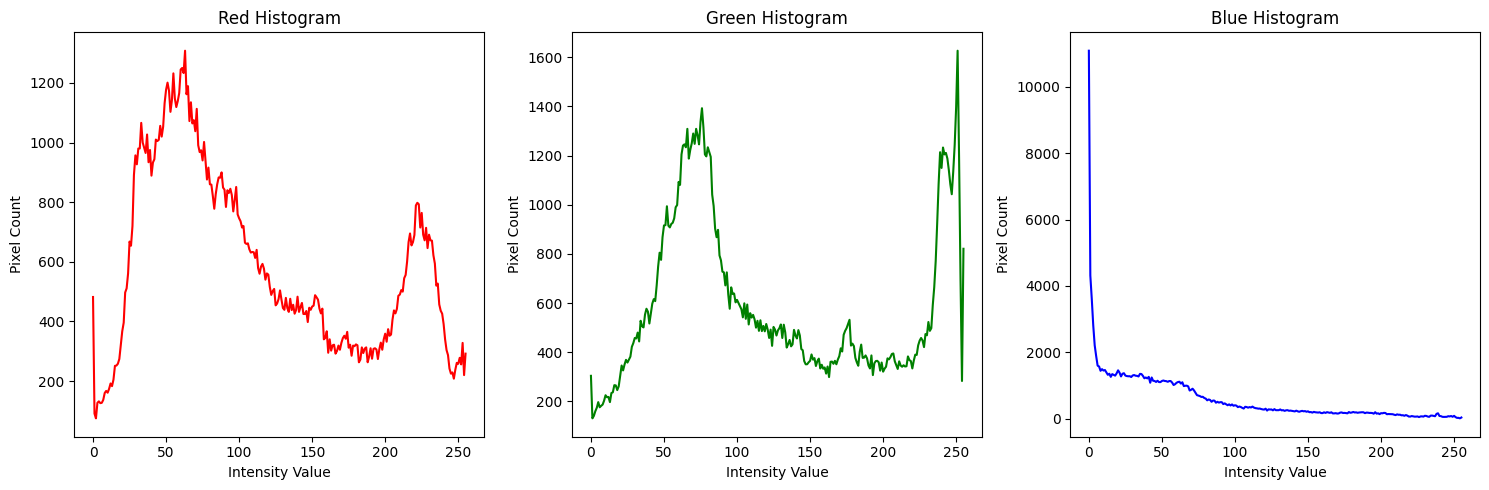

In [18]:
colors = ('r', 'g', 'b')
titles = ('Red Histogram', 'Green Histogram', 'Blue Histogram')

plt.figure(figsize=(15, 5))

# Loop through the 3 color channels
for i, col in enumerate(colors):
    # calcHist parameters: [image], [channel], mask, [bins], [range]
    # channel: 0=Red, 1=Green, 2=Blue (in RGB)
    hist = cv2.calcHist([img_rgb], [i], None, [256], [0, 256])

    plt.subplot(1, 3, i + 1)
    plt.plot(hist, color=col)
    plt.title(titles[i])
    plt.xlabel('Intensity Value')
    plt.ylabel('Pixel Count')

plt.tight_layout()
plt.show()

**Image Thresholding**

05- Convert the colored image to Grayscale


In [20]:
# Thresholding works best on single-channel (gray) images.
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

06- Global Thresholding


In [21]:
# Parameters: (image, threshold_value, max_value, type)
# Any pixel brighter than 127 becomes White (255), others become Black (0).
ret, thresh_global = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)

07-Adaptive Thresholding

In [22]:
# This calculates the threshold for small regions, which is better for uneven lighting.
# Parameters: (image, max_value, method, type, block_size, constant_C)
thresh_adaptive = cv2.adaptiveThreshold(img_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                        cv2.THRESH_BINARY, 11, 2)

08-Display the results

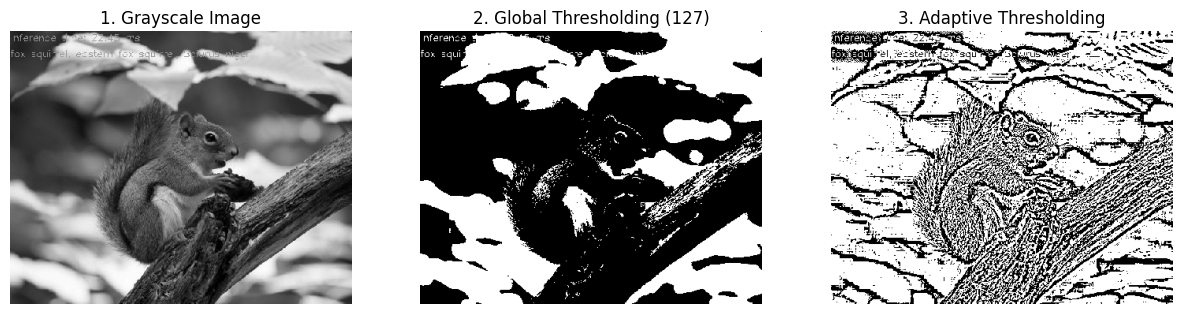

In [23]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('1. Grayscale Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(thresh_global, cmap='gray')
plt.title('2. Global Thresholding (127)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(thresh_adaptive, cmap='gray')
plt.title('3. Adaptive Thresholding')
plt.axis('off')

plt.show()

**Morphological Operations**

09- Create a Kernel (a 5x5 matrix of ones)

In [24]:
# This is the "brush" that moves over the image to apply changes.
kernel = np.ones((5, 5), np.uint8)

10-Perform Dilation (Makes white objects thicker/larger)

In [25]:
img_dilation = cv2.dilate(thresh_global, kernel, iterations=1)

11-Perform Erosion (Makes white objects thinner/smaller)

In [26]:
img_erosion = cv2.erode(thresh_global, kernel, iterations=1)

12-Perform Opening (Erosion followed by Dilation - removes small white noise)

In [27]:
img_opening = cv2.morphologyEx(thresh_global, cv2.MORPH_OPEN, kernel)

13-Perform Closing (Dilation followed by Erosion - fills small holes)

In [28]:
img_closing = cv2.morphologyEx(thresh_global, cv2.MORPH_CLOSE, kernel)

14-Display the results

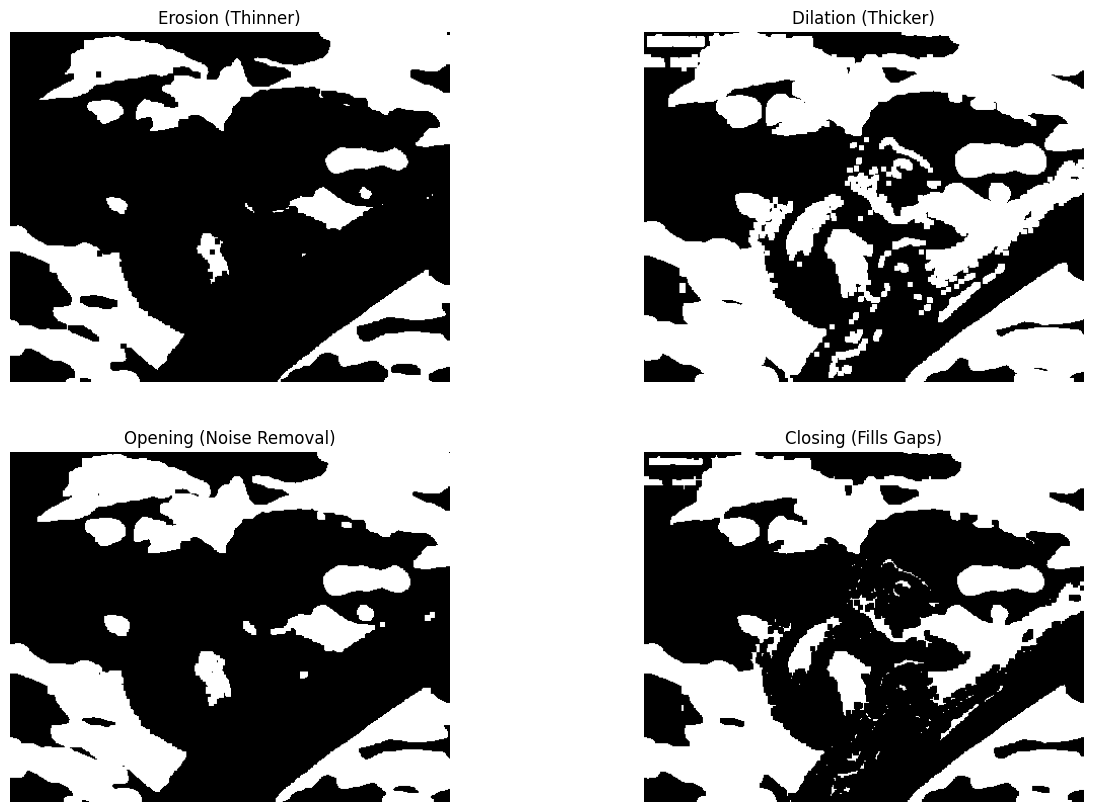

In [29]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.imshow(img_erosion, cmap='gray')
plt.title('Erosion (Thinner)')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(img_dilation, cmap='gray')
plt.title('Dilation (Thicker)')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(img_opening, cmap='gray')
plt.title('Opening (Noise Removal)')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(img_closing, cmap='gray')
plt.title('Closing (Fills Gaps)')
plt.axis('off')

plt.show()